<h1 style="text-align:center">Muon Scattering Angle Analysis for MCS </h1>

<p style="text-align:center"> Analyzing muon scattering angle distributions using gaussians and double-gaussian functions to study effectivess of MCS energy estimation.</p>

<p style="text-align:center"> NOTICE: Open this notebook using likelihoodpid venv.</p>

# 1. import and open files

In [2]:
import os
import re

from multiprocessing import Pool, cpu_count
from scipy import stats
from tqdm.auto import tqdm

import ROOT
from ROOT import TMath, TF1, TCanvas, TFormula
from ROOT import gROOT, gObjectTable
from array import array
#import uproot
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

import pickle

from scipy.interpolate import CubicSpline
from scipy import stats
from scipy import integrate
import math
    

/home/sungbino/py/likelihoodpid/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
version = "v10_14_02_02"

In [4]:
input_file = "/home/xpuig/cafpyana/mcs_df_test.df"

print("keys")
#splh.print_keys(input_file)

keys


# 2. Using PyROOT to graph a Gaussian and Double Gaussian

In [5]:
# Read the muon trajectory dataframe

muon_df = pd.read_hdf(input_file, key="muon_traj_0")

#Finding energies at each breakpoint
muonEnergies = []
momenta = muon_df["resranges_fwd_P"]
bp = 0
mu_mass = .1057 #GeV/c^2
numRows = momenta.shape[0]
plist = []
eType = []
while bp < numRows:
    p = momenta.values[bp]
    plist.append(p)
    E = (((p**2.)+(mu_mass**2.))**0.5) # E^2 = p^2c^2+(mc^2)^2 (Energy-momentum formula). c=1, so E = sqrt(p^2+m^2)
    Efloat = E.item()
    muonEnergies.append(Efloat)
    
    bp += 1
      
#Adding energies list as a column of muon df
muon_energy = pd.DataFrame(muonEnergies)
muon_df['true_energy'] = muon_energy
muon_energy

muon_df

dtheta  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint               
0        37    0              0                       0            11.840896   
                                                      1            55.287853   
                                                      2            59.696652   
                                                      3            54.304908   
                                                      4            76.847598   
...                                                                      ...   
187      3289  0              0                       8            34.512903   
                                                      9            64.239622   
                                                      10          132.004917   
                                                      11          239.210556   
                                                      12          173.482606   

                                                                  dtheta_xz  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint              
0        37    0              0                       0            2.439479   
                                                      1          -78.103503   
                                                      2          -85.587590   
                                                      3           45.152272   
                                                      4          -41.817348   
...                                                                     ...   
187      3289  0              0                       8           26.970767   
                                                      9           26.190330   
                                                      10           4.910601   
                                                      11          65.163832   
                                                      12          72.217131   

                                                                   dtheta_yz  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint               
0        37    0              0                       0            11.705682   
                                                      1           -27.849713   
                                                      2           -49.877536   
                                                      3            61.188732   
                                                      4            47.135814   
...                                                                      ...   
187      3289  0              0                       8            26.392837   
                                                      9            77.966628   
                                                      10          178.838108   
                                                      11          324.762013   
                                                      12          233.823269   

                                                                  angle_xz_rot  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint                 
0        37    0              0                       0              11.450756   
                                                      1              -6.717308   
                                                      2             -30.905680   
                                                      3              52.651055   
                                                      4              58.659706   
...                                                                        ...   
187      3289  0              0                       8              20.871040   
                                                      9              58.155369   
                                                      10            131.929615   
                                                      11  

In [6]:
def th1_from_series(series, name=r"$d\theta_{xz}$", title="dQ/dx;dQ/dx [A.U./cm];Counts",
                    nbins=100, xmin=-250.0, xmax=250.0, weights=None, edges=None):
    # drop NaNs
    vals = series.to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    if weights is not None:
        w = np.asarray(weights, dtype=float)
        w = w[~np.isnan(series.to_numpy())]
    else:
        w = None

    # binning
    if edges is None:
        edges = np.linspace(xmin, xmax, nbins + 1)
    else:
        edges = np.asarray(edges, dtype=float)
        nbins = len(edges) - 1

    # histogram with numpy
    counts, edges = np.histogram(vals, bins=edges, weights=w)

    # make TH1 with variable binning
    h = ROOT.TH1F(name, title, nbins, array('d', edges))
    h.Sumw2()
    for i, c in enumerate(counts, start=1):
        h.SetBinContent(i, float(c))
        # Set sqrt(N) if unweighted; else keep Sumw2 weights
        if w is None:
            h.SetBinError(i, np.sqrt(c))
    return h

In [7]:
ROOT.gInterpreter.Declare(r"""
#include "TMath.h"
double gaus_cpp(double *x, double *p) {
  const double A = p[0];
  const double mu = p[1];
  const double sig = p[2];

  if (sig <= 0) return 0.0;

  return A*exp(-0.5*(pow(((x[0]-mu)/sig),2)));
} 

double double_gaus_cpp(double *x, double *p) {
  return gaus_cpp(x, p) + gaus_cpp(x, p+3); 
}  
                          
double double_gaus_norm(double *x, double *p) {
  const double scale = p[0];
  const double A = p[1];
  const double mu1 = p[2];
  const double sig1 = p[3];
  const double mu2 = p[4];
  const double sig2 = p[5];

  return scale*A*exp(-0.5*(pow(((x[0]-mu1)/sig1),2)))+scale*(1-A)*exp(-0.5*(pow(((x[0]-mu2)/sig2),2)));                                                
}                                                              
""")

True

<h2 style="text-align: center">Single Gaussian</h2>

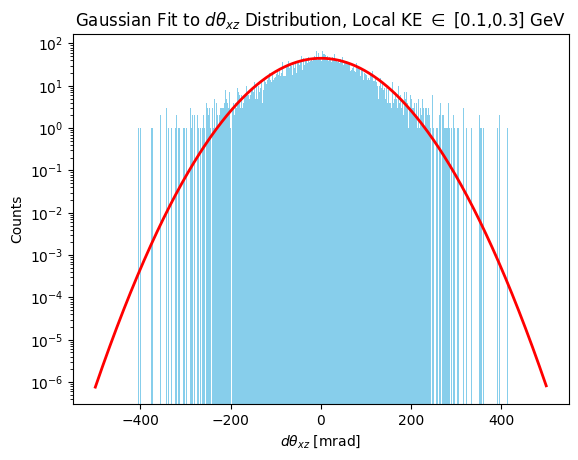

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      384.288
NDf                       =           97
Edm                       =   2.9315e-08
NCalls                    =          122
p0                        =      419.407   +/-   4.32283     
p1                        =     0.502772   +/-   0.640783    
p2                        =      83.6682   +/-   0.603553    


Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1


In [8]:
def gaus_fit(df, column, energyBounds = [0.1,0.3], name="gaus",nbins=1000):
    series = df[column]
    e1 = energyBounds[0]
    e2 = energyBounds[1]
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > e1 and muonEnergies[counter] < e2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    func1 = TF1('func1', ROOT.gaus_cpp, -500, 500, 3) #Create gaussian function with 3 parameters
    func1.SetParameters(0.78, 0.452, 95)
    h_dtheta_xz = th1_from_series(seriesNew, name=name) #Making TH1 Object to fit to the data


    h_dtheta_xz.Fit(func1, "S") #Fitting the gaussian function to the data
    area,mu,sigma = func1.GetParameter(0), func1.GetParameter(1), func1.GetParameter(2) #Getting the parameters of the fitted gaussian function

    bin_heights, bin_borders, _ = plt.hist(seriesNew, bins=nbins, range=(-500, 500), label='Fitted Gaussian', color='skyblue',log=True)
    norm = len(seriesNew) * (bin_borders[1] - bin_borders[0])

    x = np.linspace(-500, 500, nbins)
    pdf = stats.norm.pdf(x, mu, sigma) * norm #Probability Density Function

    
    plt.plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian')
    plt.xlabel(r"$d\theta_{xz}$ [mrad]")
    plt.ylabel("Counts")
    plt.title(r"Gaussian Fit to $d\theta_{xz}$ Distribution, Local KE $\in$ ["+ str(e1) + "," + str(e2) + "] GeV")

    plt.show()

    return [area, mu, sigma]

core_params =gaus_fit(muon_df, 'dtheta_xz', energyBounds=[0.1, 0.3], name=r"$d\theta_{xz}$", nbins=2000)

<h2 style='text-align: center'>Double Gaussian Fitting<h2>

Integral of histogram:  18466.0


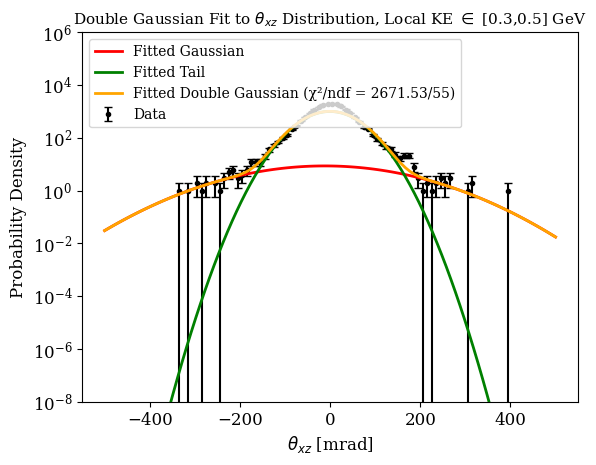

fraction            0.008549
mu                -11.783993
sigma             145.356293
mu_tail            -0.375387
sigma_tail         49.576934
fraction_err        0.003583
mu_err             10.037983
sigma_err          25.005767
mu_tail_err         0.412785
sigma_tail_err      0.340322
dtype: float64

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      2671.53
NDf                       =           55
Edm                       =  1.66766e-05
NCalls                    =          769
p0                        =         1000   +/-   0.157412     	 (limited)
p1                        =     0.008549   +/-   0.00358287   	 (limited)
p2                        =      -11.784   +/-   10.038       	 (limited)
p3                        =      145.356   +/-   25.0058      	 (limited)
p4                        =    -0.375387   +/-   0.412785     	 (limited)
p5                        =      49.5769   +/-   0.340322     	 (limited)


Warning in <TROOT::Append>: Replacing existing TH1: $\theta_{xz}$ (Potential memory leak).
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [64]:
def double_gaus_fit_5param(df,column,energyBounds=[],name="",core=False,tail=False,nbins=1000):
    plt.rc('font', family='serif', size=12)
    series = df[column]
    e1 = energyBounds[0]
    e2 = energyBounds[1]
    #parameters = [420.,0.98,0.,70.,0.,300.5]
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] >= e1 and muonEnergies[counter] <= e2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    func1 = TF1('func1', ROOT.double_gaus_norm, -500, 500, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
    #func1.SetParameters(410., 0.452, 70., 0.4972, 300.5) #[0.1,0.3 init]
    func1.SetParameters(420.,0.98,0.,90.,0.,600.5)
    #func1.SetParameters(420., 0.98, 0., 70., 0., 400.5)  
    # fit range for scaling factor
    func1.SetParLimits(0, 0., 1000.)
    # fit ranges for area fraction 
    func1.SetParLimits(1, 0., 1.) #or try .5

    # fit ranges for sigma
    func1.SetParLimits(3, 0., 420.)
    func1.SetParLimits(5, 0., 600.)

    #fit ranges for mu
    func1.SetParLimits(2, -20., 20.)
    func1.SetParLimits(4, -20., 20.)

    #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
    h_dtheta_xz = th1_from_series(seriesNew, name=name, nbins=nbins, xmin=-500, xmax=500) #Making TH1 Object to fit to the data
    #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
    print("Integral of histogram: ", h_dtheta_xz.Integral())
    h_dtheta_xz.Fit(func1, "S") #Fitting the double gaussian function to the data
   
    mu,sigma = func1.GetParameter(2), func1.GetParameter(3) #Getting the parameters of the fitted double gaussian function
    mu_tail,sigma_tail = func1.GetParameter(4), func1.GetParameter(5) #Getting the parameters of the fitted double gaussian function
    fraction,scale = func1.GetParameter(1), func1.GetParameter(0) #Getting the parameters of the fitted double gaussian function
    #Get Parameter Errors

    mu_err,sigma_err = func1.GetParError(2), func1.GetParError(3)
    mu_tail_err,sigma_tail_err = func1.GetParError(4), func1.GetParError(5)
    scale_err,fraction_err = func1.GetParError(0), func1.GetParError(1)

    #Getting fit results (chi squared, ndf)
    chi2 = func1.GetChisquare()
    ndf = func1.GetNDF()
    chi2_ndf = chi2/ndf

    bin_heights, bin_borders = np.histogram(seriesNew, bins=nbins, range=(-500, 500)) #Normalizing histogram to 1
    bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
    plt.errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='Data',markersize=3, capsize=3, linewidth=1.5, zorder=1)

    plt.yscale('log')

    x = np.linspace(-500, 500, nbins)
    pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
    pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
    double_pdf = pdf + pdf_tail
    
    if core: plt.plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
    if tail: plt.plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
    plt.plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian (χ²/ndf = {round(chi2,2)}/{ndf})', zorder=4)

    #change y axis 1000 more to fit legends
    plt.legend(loc='upper left', fontsize=10)
    plt.ylim(0.00000001,1000000)

    plt.xlabel(r"$\theta_{xz}$ [mrad]")
    plt.ylabel("Probability Density")
    plt.title(r"Double Gaussian Fit to $\theta_{xz}$ Distribution, Local KE $\in$ ["+ str(e1) + "," + str(e2) + "] GeV",size=11)
    #plt.tight_layout()

    plt.show()

    fitResult = pd.Series([fraction, mu, sigma, mu_tail, sigma_tail, fraction_err,mu_err, sigma_err, mu_tail_err, sigma_tail_err],index=['fraction', 'mu', 'sigma', 'mu_tail', 'sigma_tail', 'fraction_err', 'mu_err', 'sigma_err', 'mu_tail_err', 'sigma_tail_err'])

    return fitResult

dgaus_fitResult = double_gaus_fit_5param(muon_df, 'dtheta_xz', energyBounds=[0.3, 0.5], name=r"$\theta_{xz}$",nbins=100,core=True,tail=True)
dgaus_fitResult    

# 3. Double Gaussian Subplots

In [25]:
def double_gaus_sub_5param(df,column,idx,energyBounds=[],name="",core=False,tail=False,nbins=1000):
    plt.rc('font', family='serif', size=12)
    series = df[column]
    e1 = energyBounds[0]
    e2 = energyBounds[1]
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > e1 and muonEnergies[counter] < e2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    func1 = TF1('func1', ROOT.double_gaus_norm, -500, 500, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
    #func1.SetParameters(410., 0.452, 70., 0.4972, 300.5) #[0.1,0.3 init]
    func1.SetParameters(420.,0.98,0.,70.,0,300.5)
    #func1.SetParameters(420., 0.5, 500., 2., 40.1, 1000.5)  
    # fit range for scaling factor
    func1.SetParLimits(0, 0., 1000.)
    # fit ranges for area fraction 
    func1.SetParLimits(1, 0., 1.) #or try .5

    # fit ranges for sigma
    func1.SetParLimits(3, 0., 420.)
    func1.SetParLimits(5, 0., 600.)

    #fit ranges for mu
    func1.SetParLimits(2, -20., 20.)
    func1.SetParLimits(4, -20., 20.)

    #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
    h_dtheta_xz = th1_from_series(seriesNew, name=name, nbins=nbins, xmin=-500, xmax=500) #Making TH1 Object to fit to the data
    #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
    print("Integral of histogram: ", h_dtheta_xz.Integral())
    h_dtheta_xz.Fit(func1, "S") #Fitting the double gaussian function to the data
   
    mu,sigma = func1.GetParameter(2), func1.GetParameter(3) #Getting the parameters of the fitted double gaussian function
    mu_tail,sigma_tail = func1.GetParameter(4), func1.GetParameter(5) #Getting the parameters of the fitted double gaussian function
    fraction,scale = func1.GetParameter(1), func1.GetParameter(0) #Getting the parameters of the fitted double gaussian function
    #Get Parameter Errors

    mu_err,sigma_err = func1.GetParError(2), func1.GetParError(3)
    mu_tail_err,sigma_tail_err = func1.GetParError(4), func1.GetParError(5)
    scale_err,fraction_err = func1.GetParError(0), func1.GetParError(1)

    #Getting fit results (chi squared, ndf)
    chi2 = func1.GetChisquare()
    ndf = func1.GetNDF()
    chi2_ndf = chi2/ndf

    bin_heights, bin_borders = np.histogram(seriesNew, bins=nbins, range=(-500, 500)) #Normalizing histogram to 1
    bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
    axs[idx].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', label='Data',markersize=3, capsize=3, linewidth=1.5, zorder=1)

    axs[idx].set_yscale('log')

    x = np.linspace(-500, 500, nbins)
    pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
    pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
    double_pdf = pdf + pdf_tail
    
    if core: axs[idx].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
    if tail: axs[idx].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
    axs[idx].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian (χ²/ndf = {chi2_ndf:.2f})', zorder=4)

    #change y axis 1000 more to fit legends
    axs[idx].legend(loc='upper left', fontsize=10)
    axs[idx].set_ylim(0.00000001,1000000)

    axs[idx].set_xlabel(r"$\theta_{xz}$ [mrad]")
    axs[idx].set_ylabel("Probability Density")
    axs[idx].set_title(r"Double Gaussian Fit to $\theta_{xz}$ Distribution, Local KE $\in$ ["+ str(e1) + "," + str(e2) + "] GeV",size=11)
    #axs[idx].tight_layout()

    plt.show()

    fitResult = pd.Series([fraction, mu, sigma, mu_tail, sigma_tail, fraction_err,mu_err, sigma_err, mu_tail_err, sigma_tail_err],index=['fraction', 'mu', 'sigma', 'mu_tail', 'sigma_tail', 'fraction_err', 'mu_err', 'sigma_err', 'mu_tail_err', 'sigma_tail_err'])

    return fitResult

[0.1, 0.3, 0.5, 0.7, 0.9]
4
Integral of histogram:  18287.0
Integral of histogram:  18466.0
Integral of histogram:  7199.0
Integral of histogram:  1841.0


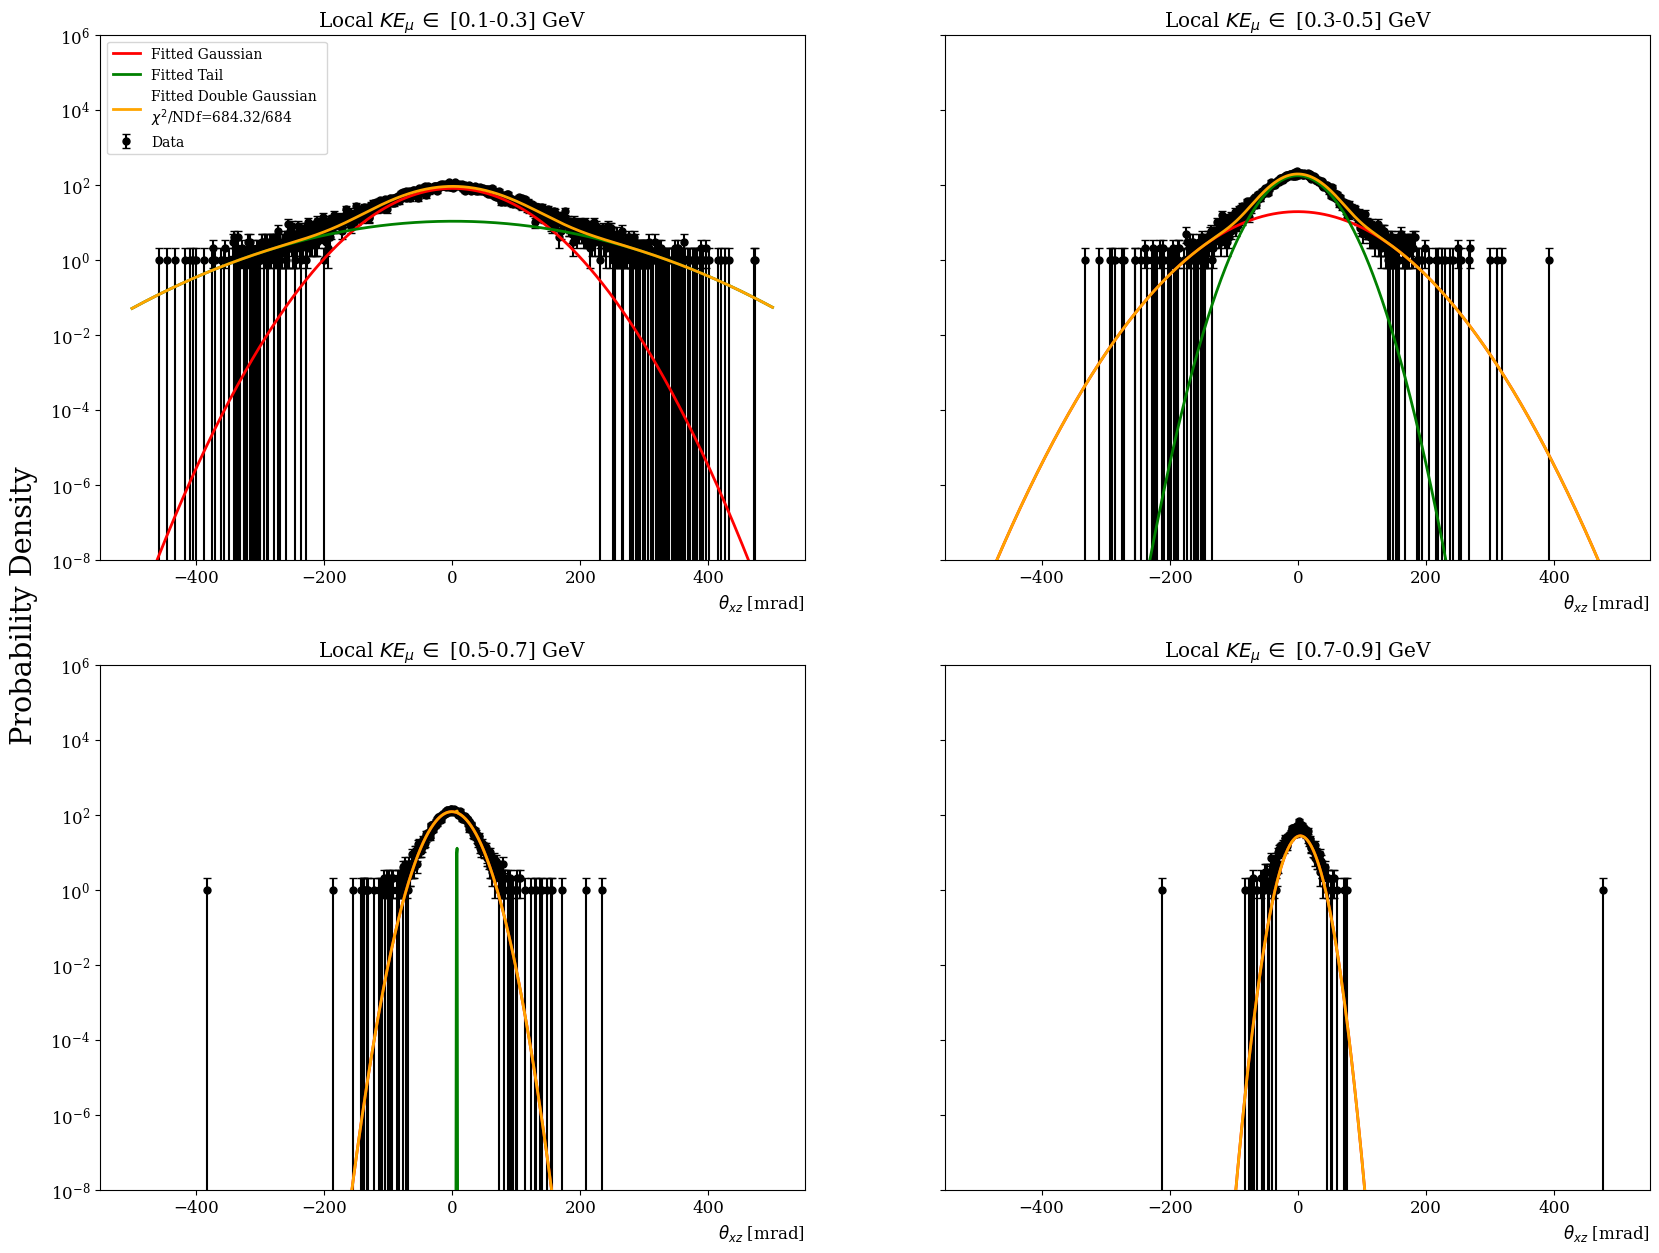

""


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      684.317
NDf                       =          684
Edm                       =  1.44272e-06
NCalls                    =          691
p0                        =      90.3857   +/-   1.0795       	 (limited)
p1                        =     0.882429   +/-   0.0225255    	 (limited)
p2                        =     0.784812   +/-   0.775769     	 (limited)
p3                        =       68.339   +/-   1.57071      	 (limited)
p4                        =      1.60648   +/-   3.40045      	 (limited)
p5                        =      153.286   +/-   9.99869      	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      392.155
NDf                       =          389
Edm                       =  8.01194e-07
NCalls                    =          563
p0                        =      193.333   +/-   2.28164      	 (limited)
p1          

Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Warning in <Fit>: Abnormal termination of minimization.


In [52]:
def double_gaus_subplots(df,column,energyBounds=[0.1,0.9],xname="",core=False,tail=False,nbins=1000):
    series = df[column]
    dgaus_parameters = pd.DataFrame()
    eb1 = energyBounds[0]
    eb2 = energyBounds[1]
    #print(eb2)
    eStep = 0.2
    energyBins = []
    energy = eb1
    while energy < eb2:
        energyBins.append(round(energy, 2))
        energy += eStep
    #energyBins.append(eb2)
    print(energyBins)
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > eb1 and muonEnergies[counter] < eb2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    print(len(energyBins)-1)
    
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 15),sharey=True)
    axs = axs.flatten()

    #parameters=[420.,0.98,0.,70.,0,300.5] -> Good init parameters for [0.1-0.3] GeV
    for i in range(len(energyBins)-1):
        count = 0
        e1 = energyBins[i]
        e2 = energyBins[i+1]
        listNew2 = []
        parameterStr = input(f"Type your desired initial parameters for [{e1}-{e2}] GeV"+"\n"+"Make sure they're in the following order, each separated by a comma:"+"\n"+"Scale factor,Area fraction,mu1,sigma1,mu2,sigma2.")
        params = parameterStr.split(",")
        for j in range(len(params)):
            params[j] = float(params[j])
        #print(params)
        while count < len(seriesNew):
            if energyNew[count] >= e1 and energyNew[count] <= e2:
                listNew2.append(seriesNew[count])
            count += 1
        seriesNew2 = pd.Series(listNew2)
     
        func = TF1('func', ROOT.double_gaus_norm, -500, 500, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
        func.SetParameters(params[0],params[1],params[2],params[3],params[4],params[5]) 
     
        #[0.1,0.3 init]
        #func1.SetParameters(420.,0.02,0.,70.,0,300.5) #0.02 area fraction works as opposed to 0.98- so I suppose this param is for the tail gaus.
    
        # fit range for scaling factor
        func.SetParLimits(0, 0., 1000.)
        # fit range for area fraction 
        func.SetParLimits(1, 0., 1.) #or try .5

        # fit ranges for sigma1, sigma2
        func.SetParLimits(3, 0., 420.)
        func.SetParLimits(5, 0., 600.)

        #fit ranges for mu1, mu2
        func.SetParLimits(2, -20., 20.)
        func.SetParLimits(4, -20., 20.)

        #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
        h_dtheta_xz = th1_from_series(seriesNew2, name='roothist', nbins=nbins, xmin=-500, xmax=500) #Making TH1 Object to fit to the data
        #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
        print("Integral of histogram: ", h_dtheta_xz.Integral())
        h_dtheta_xz.Fit(func, "S") #Fitting the double gaussian function to the data
   
        mu,sigma = func.GetParameter(2), func.GetParameter(3) #Getting the parameters of the fitted double gaussian function
        mu_tail,sigma_tail = func.GetParameter(4), func.GetParameter(5) #Getting the parameters of the fitted double gaussian function
        fraction,scale = func.GetParameter(1), func.GetParameter(0) #Getting the parameters of the fitted double gaussian function
        #Get Parameter Errors

        mu_err,sigma_err = func.GetParError(2), func.GetParError(3)
        mu_tail_err,sigma_tail_err = func.GetParError(4), func.GetParError(5)
        scale_err,fraction_err = func.GetParError(0), func.GetParError(1)

        #Getting fit results (chi squared, ndf)
        chi2 = func.GetChisquare()
        ndf = func.GetNDF()
        chi2_ndf = chi2/ndf

        bin_heights, bin_borders = np.histogram(seriesNew2, bins=nbins, range=(-500, 500)) #Normalizing histogram to 1
        bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2

        plt.yscale('log')

        x = np.linspace(-500, 500, nbins)
        pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        x = np.linspace(-500, 500, nbins)
        pdf = scale * fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale * (1 - fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        axs[i].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', label='Data',markersize=5, capsize=3, linewidth=1.5, zorder=1)
        axs[i].set_yscale('log')
        if core: axs[i].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
        if tail: axs[i].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
        axs[i].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian \n'+r'$\chi^2$/NDf'+f"={round(chi2,2)}/{ndf}", zorder=4)
        axs[i].set_title(r"Local $KE_{\mu} \, \in$ "+f"[{e1}-{e2}] GeV")
        axs[i].set_xlabel(xname, loc='right')

        ser = pd.Series({f"KE in [{e1}-{e2}]":[fraction,mu,sigma,mu_tail,sigma_tail,fraction_err,mu_err,sigma_err,mu_tail_err,sigma_tail_err]})
        pd.concat([dgaus_parameters,ser])

    #change y axis 1000 more to fit legends
    axs[0].legend(loc='upper left', fontsize=10)
    axs[0].set_ylim(0.00000001,1000000)
    fig.text(0.08, 0.5, 'Probability Density', va='center', rotation='vertical',size='xx-large')
    plt.tight_layout
    plt.show()

    return dgaus_parameters


dgaus_fitResults = double_gaus_subplots(muon_df, 'dtheta_xz', xname=r'$\theta_{xz}$ [mrad]',energyBounds=[0.1, 0.9], core=True, tail=True, nbins=1000)
dgaus_fitResults